The block below imports a necessary module and checks if you are in the right directory. If you do not see a list of python files when you run the block, please make sure you have uploaded the zip file and unzipped it.

In [1]:
import matplotlib.pyplot as plt

%pwd
%ls




 atomgenerator.py    embedmodel.py       kbencoder.py          nnunifier.py
 autoencoder.py      evaluate.py         kbparser.py           reasoner.py
 basictypes.py       gameofthrones.txt   knowledgebase.py      termwalk.py
 chainbased.py       gen_queries.py      mr_back_reasoner.py   vocab.py
'CSE 327 P4.ipynb'   helpers/            nnreasoner.py


If you want to create a random knowledge base, run the following code.

Creates the files:

* randomKB.txt - A random KB generated using 10 predicates and 100 constants.
* vocab.pkl - Indexes the full set of predicates, constants and variables used by the knowledge base.

In [2]:
!python kbencoder.py --generate_kb --new_vocab --save_vocab
!head randomKB.txt

Classes: 1000000000.0
Max arity: 4
KB generated (150)
p3(a40, a79).
p7(a93, a47).
p4(a12).
p4(a10).
p3(a62, a6).
p9(a32, a0).
p5(a5).
p8(a99, a69, a27, a21).
p2(a13, a30).
p0(a51, a54, a21).


The following code prepares an existing knowledge base (KB) for use. To use a KB of your choosing, replace gameofthrones.txt with the file name of any KB you want to use.

Creates the file:

*   vocab.pkl - Indexes the full set of predicates, constants and variables used by the knowledge base.

In [3]:
!python kbencoder.py --kb_path gameofthrones.txt --vocab_from_kb --save_vocab


Creating vocabulary from last gameofthrones.txt knowledge base


Train a neural net to convert first-order logic atoms into meaningful numeric vectors. We call these vectors "embeddings," and the learned model the embedding model. The code creates random atoms and then uses a mechanism known as triplet loss to place unifying atoms closer together.

Creates the files:

*   rKB_model.pth - Saves the learned weights for the embedding model
*   training_loss-45-106-2-50.png - A plot of the training loss after each epoch. This file's name depends on the vocabulary of your KB: the four numbers are number of predicates, number of constants, max arity of the predicates, and the embedding size used. If you changed the KB, you'll need to look up the name in your drive and update the code block that displays this file.


In [4]:
!python kbencoder.py --kb_path gameofthrones.txt --train_unification_model



Using cuda device
Uni model embed size: 50
 [████████████████████] 3500/3500 Anchors generated                                                 
 [████████████████████] 70000/70000 Triplets generated                                              
 [█████---------------] 18104/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [█████████████-------] 48277/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [████████████████████] 70000/70000 Triplet encodings                                               
Early stopping triggered-------------] 33.1% Epoch | [Epoch 166/500, Training Loss: 0.0629, Validation Loss: 0.2583]
Saved model.
Saved plot.
unification model generated


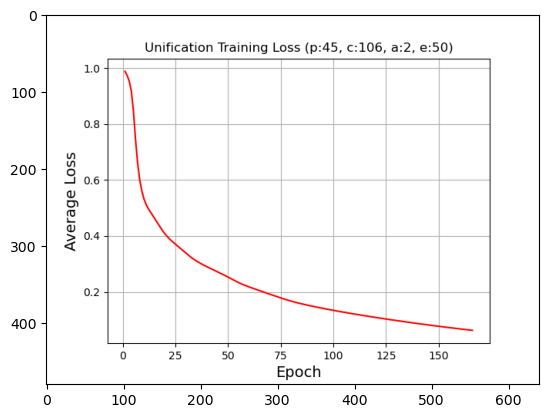

In [8]:
img = plt.imread('training_loss-45-106-2-50.png')
plt. imshow(img)

Generate a set of train and test queries from your knowledge base. This will also generate the deductive closure (all facts that can be inferred) of your KB using forward-chaining.

Produces the files:

*  all_facts.txt - A list of all facts that can be inferred from the KB. This is used to generate queries that are guaranteed to have an answer.
*  train_queries.txt - A set of training queries where each will have at least one answer.
*  test_queries.txt - A set of test queries where each will have at least one answer.


In [9]:
!python kbencoder.py --kb_path gameofthrones.txt -g

Generating facts list...
Forward chaining depth: 1
New facts: 442
Forward chaining depth: 2
New facts: 175
Forward chaining depth: 3
New facts: 82
Forward chaining depth: 4
New facts: 12
Forward chaining depth: 5
New facts: 1
Forward chaining depth: 6
New facts: 2
Forward chaining depth: 7

Facts list generated
714 total facts. Max depth = 6

Number of queries: 200
100 training queries generated
100 testing queries generated


Create a training set for the scoring model. The examples will consist of goal, rule, score pairs, where a score of 1 means the rule can solve the goal, and 0 means it cannot. It runs the full set of training queries with a randomized backward-chaining process. This step can sometimes take a long time and is not able to take advantage of a GPU (with the gameofthrones KB it took ~45 minutes).

Creates a file:
*  mr_train_examples.csv - Contains a line for each goal/rule/score example.

In [1]:
!python kbencoder.py --kb_path gameofthrones.txt -p

running training queries...
Negative facts will be generated
1: [child(_EX2, rhaegar_targaryen)]
min depth: 2                                                                                        
Nodes: 5                                                                                            
Answers: 3                                                                                          

2: [father(_EX6, aegon_targaryen)]
min depth: 3                                                                                        
Nodes: 5                                                                                            
Answers: 1                                                                                          

3: [descendant(robert_baratheon, X), parent(X, Y), father(steffon_baratheon, Y), mother(X, Y)]
min depth: 3                                                                                        
Nodes: 500                                                      

Train the scoring model. This step will usually take several minutes, especially if you are not using a GPU (for the gameofthrones KB, it takes about 30 minutes on CPU).

Creates a file:
* uni_mr_model.pt - Contains the weights for the learned scoring model

In [2]:
!python nnreasoner.py --embed_type unification

States from vocab: vocab
Num predicates: 45
Max arity: 2
Num constants: 106
Num variables: 10

Training unification
Embed size: 50
Reading examples from mr_train_examples.csv
Parsing examples...
Generating embeddings...
Embedding input size: 277
 [███████████████] 34609/34609 Prepping examples                                                    
Loaded data...
Using cuda device
/opt/tljh/user/envs/cse327python311/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
0	0.61385 (-)
50	0.31681 (-0.0061)
100	0.27049 (-0.0036)
150	0.24313 (-0.0026)
200	0.22897 (-0.0020)
250	0.21627 (-0.0017)
300	0.20388 (-0.0014)
350	0.19261 (-0.0013)
400	0.18442 (-0.0011)
450	0.18001 (-0.0010)
500	0.17603 (-0.0009)
550	0.16999 (-0.0008)
600	0.16517 (-0.0008)
650	0.16248 (-0.0007)
700	0.16121 (-0.000

In [4]:
img = plt.imread('guided_loss-unification45-106-2-50.png')
plt. imshow(img)

NameError: name 'plt' is not defined

Evaluate the scoring model by running evaluate.py. We compare the standard backward-chaining algorithm (-s) with the one that uses our learned scoring model (-u).

The output lists each query, and then provides a line that gives information about query execution. These are: number of nodes explored in the tree, depth of the solution, execution time in seconds, and the speed of exploring the tree (nodes per second).

The names of the files produced depend on the KB used and the options selected. The code below produces the files:

* std-45-106-2-50.csv - A CSV file with query results for the standard backward-chaining algorithm
* ming-45-106-2-50.csv - A CSV file with query results for the learned reasoner. ming stands for "min scoring goal" and is the default strategy for deciding how to make use of the scores

If you use a different knowledge base, you will likely get different file names that depend on the features of that KB's vocabulary.

In [ ]:
!python evaluate.py --kb gameofthrones.txt -s
!python evaluate.py --kb gameofthrones.txt -u

using cuda device
STANDARD

Query 1: [mother(X, kevan_lannister), parent(X, tywin_lannister)]
32 :: 4 - 00:00:00 (1592 nps)                                                                       

Query 2: [male(X), kill(arya_stark, X), night_walkers_king(X), who_brought_the_winter(X), night_walker(X)]
33 :: 7 - 00:00:00 (16703 nps)                                                                      

Query 3: [ancestor(Z, _EX1)]
3 :: 2 - 00:00:00 (1962 nps)                                                                        

Query 4: [ancestor(lewyn_martell, _EX5)]
3 :: 2 - 00:00:00 (3073 nps)                                                                        

Query 5: [descendant(X, _EX6)]
4 :: 3 - 00:00:00 (3333 nps)                                                                        

Query 6: [descendant(_EX5, _EX6)]
4 :: 3 - 00:00:00 (3312 nps)                                                                        

Query 7: [father(_EX2, maron_greyjoy)]
8 :: 3 - 00:0

The results suggest only minor improvements for the gameofthrones KB: on average 3.75 vs. 4.39 node per query when I ran it. You may get different results due to the randomization of training and random selection of test queries. Larger, more complex KBs can see much larger improvements, sometimes an order of magnitude or more.

The code below shows the first 10 lines of each query result file. A given line has:
* query sequence number
* configuration name
* number of nodes explored
* depth of solution (0 if no solution found)
* did the system find a solution (true/false)
* time in seconds

You can import these files into a spreadsheet in order to create plots or summary statistics.

In [7]:
!head std-45-106-2-50.csv
!head ming-45-106-2-50.csv

query,std reasoner,std nodes explored,std min depth,success,time
1,std,32,4,True,0.02009496600000027
2,std,33,7,True,0.0019755799999998658
3,std,3,2,True,0.0015283219999995268
4,std,3,2,True,0.0009759840000000963
5,std,4,3,True,0.0011998389999998693
6,std,4,3,True,0.0012074389999998658
7,std,8,3,True,0.0036835729999999955
8,std,59,13,True,0.017347399000000152
9,std,7,6,True,0.002562507999999575
query,ming reasoner,ming nodes explored,ming min depth,success,time
1,ming,5,4,True,0.658156786000001
2,ming,8,7,True,0.24486948199999858
3,ming,3,2,True,0.5300766029999995
4,ming,3,2,True,0.032032372999999836
5,ming,8,5,True,1.560161707999999
6,ming,4,3,True,0.5252669090000008
7,ming,4,3,True,0.196291102
8,ming,587,13,True,17.392180805
9,ming,7,6,True,0.21597710900000067


STEP 5:
Use the code to generate three random KBs of sizes 200, 300, and 400. To keep from 
overwriting important files, it is recommended that you create each in its own subdirectory. 
For example, if you want to put the 400 statement KB in a directory named size400: 
cd size400 
python ..\kbencoder.py --generate_kb --num_rules 400 --new_vocab --save_vocab 

In [18]:
%cd size300
!python ../kbencoder.py --generate_kb --num_rules 300 --new_vocab --save_vocab

/data/users/jupyter-zmf227/cse327-p4-files/size300
Classes: 100000000000.0
Max arity: 5
KB generated (300)


STEP 6: 
For each random KB, train the embedding and scoring models and then compare reasoning 
using the scoring model to the standard reasoner. 

In [23]:
# prepare and train using kbencoder
!python ../kbencoder.py --kb_path randomKB.txt --train_unification_model

Using cuda device
Uni model embed size: 50
 [████████████████████] 3500/3500 Anchors generated                                                 
 [████████████████████] 70000/70000 Triplets generated                                              
 [█████---------------] 18230/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [███████████---------] 39557/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



 [██████████████████--] 64173/70000 Triplet encodings                                               

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Early stopping triggered-------------] 16.2% Epoch | [Epoch 82/500, Training Loss: 0.2868, Validation Loss: 0.6358]
Saved model.
Saved plot.
unification model generated


IGNORE ALL BELOW:

In [30]:
# will read randomKB.txt and generate mr_train_examples.csv and test_queries.txt into the size300 folder
!python ../gen_queries.py --kb_path randomKB.txt

Traceback (most recent call last):
  File "/data/users/jupyter-zmf227/cse327-p4-files/size300/../gen_queries.py", line 62, in <module>
    generate_variable_combinations('lubm_query_from_q14.txt')
  File "/data/users/jupyter-zmf227/cse327-p4-files/size300/../gen_queries.py", line 12, in generate_variable_combinations
    facts = parse_KB_file(input_file)
            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/users/jupyter-zmf227/cse327-p4-files/kbparser.py", line 74, in parse_KB_file
    with open(file_path, mode='r') as f:
         ^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'lubm_query_from_q14.txt'


In [31]:
!python ../nnreasoner.py --kb_path randomKB.txt --embed_type unification

usage: nnreasoner.py [-h] [-t TRAINING_FILE] [-s SAVE_MODEL]
                     [--num_epochs NUM_EPOCHS]
                     [--embed_type {unification,autoencoder,chainbased,termwalk}]
                     [--vocab_file VOCAB_FILE] [-e EMBED_SIZE]
                     [--embed_model_path EMBED_MODEL_PATH]
nnreasoner.py: error: unrecognized arguments: --kb_path randomKB.txt


In [29]:
# train the scoring model (nnreasoner)
!python ../nnreasoner.py --embed_type unification

States from vocab: vocab
Num predicates: 10
Max arity: 5
Num constants: 100
Num variables: 10

Training unification
Embed size: 50
Reading examples from mr_train_examples.csv
Traceback (most recent call last):
  File "/data/users/jupyter-zmf227/cse327-p4-files/size300/../nnreasoner.py", line 354, in <module>
    train_reasoning_model(
  File "/data/users/jupyter-zmf227/cse327-p4-files/size300/../nnreasoner.py", line 127, in train_reasoning_model
    with open(training_file, mode="r") as f:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'mr_train_examples.csv'


In [25]:
# evaluate and compare
!python ../evaluate.py --kb_path randomKB.txt -s
!python ../evaluate.py --kb_path randomKB.txt -u

usage: evaluate.py [-h] [--kb KB] [--qfile QFILE] [--vocab_file VOCAB_FILE]
                   [-e EMBED_SIZE] [-s] [-u]
                   [--embed_model_path EMBED_MODEL_PATH]
                   [--scoring_model_path SCORING_MODEL_PATH] [-a]
                   [--auto_model_path AUTO_MODEL_PATH]
                   [--auto_guidance_model_path AUTO_GUIDANCE_MODEL_PATH] [-t]
                   [--termwalk_guidance_model_path TERMWALK_GUIDANCE_MODEL_PATH]
                   [-c]
                   [--chainbased_guidance_model_path CHAINBASED_GUIDANCE_MODEL_PATH]
                   [--config_name CONFIG_NAME] [--use_min_score]
                   [--control {allgoals,mingoal,maxgoal}] [--trace]
                   [--explain]
evaluate.py: error: unrecognized arguments: --kb_path randomKB.txt
usage: evaluate.py [-h] [--kb KB] [--qfile QFILE] [--vocab_file VOCAB_FILE]
                   [-e EMBED_SIZE] [-s] [-u]
                   [--embed_model_path EMBED_MODEL_PATH]
                   [--sc

In [32]:
%cd ..

/data/users/jupyter-zmf227/cse327-p4-files


In [33]:
%cd size300

/data/users/jupyter-zmf227/cse327-p4-files/size300
